In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(2026)
n = 100
x = rng.uniform(-2.0, 2.0, n)
y = 2.0 - x + 5.0 * x**2 + 0.5 * rng.standard_normal(n)   # drop the noise term if you prefer

X = np.column_stack([x, x**2])

# Standardize features (zero mean, unit variance for each feature)
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_std[X_std == 0] = 1  # safeguard to avoid division by zero for constant features
X_norm = (X - X_mean) / X_std # standardizing each column in the design matrix to make them all have the same scale

# Center the target to zero mean (optional, to simplify intercept handling)
y_mean = np.mean(y)
y_centered = y - y_mean

NameError: name 'x_sorted_idx' is not defined

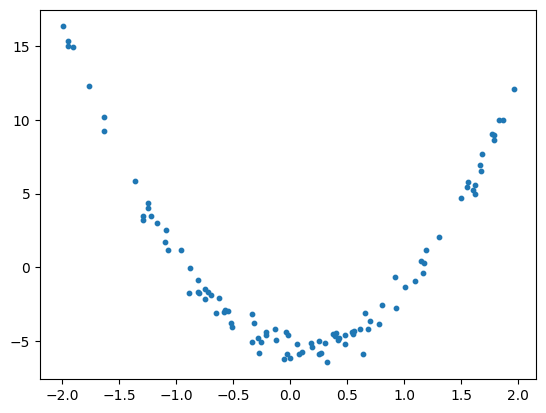

In [ ]:
# For OLS: standardized design matrix, centered y
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_norm,y_centered)
y_tilde = linreg.predict(X_norm)

x_sorted_idx = np.argsort(x.flatten())
plt.scatter(x, y_centered, s=10, label="data")
plt.plot(x.flatten()[x_sorted_idx], y_tilde.flatten()[x_sorted_idx],'r-')
plt.axis([0.0,1.0,1.5, 7.0])
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')
plt.title(r'Linear Regression fit based on sklearn')
plt.show()